Import Libraries

In [1]:
import pandas as pd
import numpy as np

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
train = pd.read_csv(
    "/content/drive/MyDrive/Hospital Readmission/Preprocessed Dataset/train_processed.csv"
)

test = pd.read_csv(
    "/content/drive/MyDrive/Hospital Readmission/Preprocessed Dataset/test_processed.csv"
)

In [4]:
print(train.columns)

Index(['admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses',
       'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other',
       'gender_Male', 'gender_Unknown/Invalid', 'age_[10-20)', 'age_[20-30)',
       'age_[30-40)', 'age_[40-50)', 'age_[50-60)', 'age_[60-70)',
       'age_[70-80)', 'age_[80-90)', 'age_[90-100)', 'max_glu_serum_>300',
       'max_glu_serum_None', 'max_glu_serum_Norm', 'A1Cresult_>8',
       'A1Cresult_None', 'A1Cresult_Norm', 'metformin_No', 'metformin_Steady',
       'metformin_Up', 'repaglinide_No', 'repaglinide_Steady',
       'repaglinide_Up', 'nateglinide_No', 'nateglinide_Steady',
       'nateglinide_Up', 'chlorpropamide_No', 'chlorpropamide_Steady',
       'chlorpropamide_Up', 'glimepiride_No', 'glimepiride_Steady',
       

In [5]:
print(train["readmitted"].value_counts())
print()
print(test["readmitted"].value_counts())

readmitted
2    43057
1    28138
0     9000
Name: count, dtype: int64

readmitted
2    10764
1     7035
0     2250
Name: count, dtype: int64


In [6]:
# 1 = <30 (Positive Class)
# 0 = >30 or NO (Negative Class)

train["readmitted"] = train["readmitted"].apply(lambda x: 1 if x == 0 else 0)
test["readmitted"] = test["readmitted"].apply(lambda x: 1 if x == 0 else 0)

In [7]:
print(train["readmitted"].value_counts())
print(test["readmitted"].value_counts())

readmitted
0    71195
1     9000
Name: count, dtype: int64
readmitted
0    17799
1     2250
Name: count, dtype: int64


In [8]:
X_train = train.drop(columns=["readmitted"])
y_train = train["readmitted"]

X_test = test.drop(columns=["readmitted"])
y_test = test["readmitted"]

Balanced LightGBM

In [9]:
import re

def clean_column_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col)
        for col in df.columns
    ]
    return df

X_train = clean_column_names(X_train)
X_test = clean_column_names(X_test)

In [10]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    objective="binary",
    class_weight="balanced",
    random_state=42,
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31
)

lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 9000, number of negative: 71195
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.078597 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1254
[LightGBM] [Info] Number of data points in the train set: 80195, number of used features: 72
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


LGBMClassifier(class_weight='balanced', learning_rate=0.03, n_estimators=500,
               objective='binary', random_state=42)

In [11]:
y_pred = lgbm.predict(X_test)

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("=" * 60)
print("Binary LightGBM")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Binary LightGBM
Accuracy : 0.6716
Precision: 0.1836
Recall   : 0.5591
F1 Score : 0.2765

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.69      0.79     17799
           1       0.18      0.56      0.28      2250

    accuracy                           0.67     20049
   macro avg       0.55      0.62      0.53     20049
weighted avg       0.84      0.67      0.73     20049



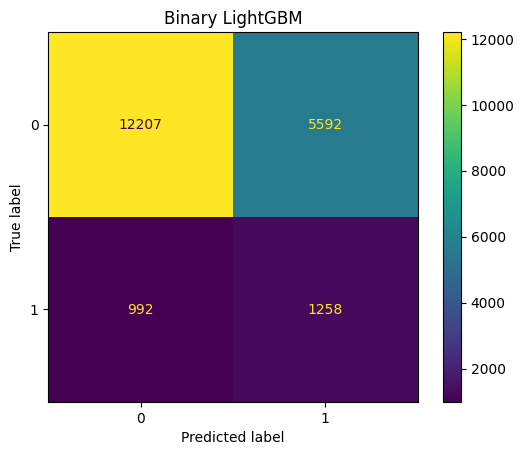

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Binary LightGBM")
plt.show()

Feature Engineering

In [14]:
train = pd.read_csv("/content/drive/MyDrive/Hospital Readmission/Preprocessed Dataset/train_processed.csv")
test = pd.read_csv("/content/drive/MyDrive/Hospital Readmission/Preprocessed Dataset/test_processed.csv")

In [15]:
train["readmitted"] = train["readmitted"].apply(lambda x: 1 if x == 0 else 0)
test["readmitted"] = test["readmitted"].apply(lambda x: 1 if x == 0 else 0)

In [16]:
X_train = train.drop(columns=["readmitted"])
y_train = train["readmitted"]

X_test = test.drop(columns=["readmitted"])
y_test = test["readmitted"]

In [17]:
X_train["service_utilization"] = (
    X_train["number_outpatient"] +
    X_train["number_inpatient"] +
    X_train["number_emergency"]
)

X_test["service_utilization"] = (
    X_test["number_outpatient"] +
    X_test["number_inpatient"] +
    X_test["number_emergency"]
)

In [18]:
import re

X_train.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', col)
    for col in X_train.columns
]

X_test.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', col)
    for col in X_test.columns
]

In [19]:
print(X_train[[
    "number_outpatient",
    "number_inpatient",
    "number_emergency",
    "service_utilization"
]].head())

   number_outpatient  number_inpatient  number_emergency  service_utilization
0          -0.290660         -0.506371         -0.215022            -1.012053
1          -0.290660         -0.506371         -0.215022            -1.012053
2           0.483382         -0.506371         -0.215022            -0.238011
3          -0.290660         -0.506371         -0.215022            -1.012053
4          -0.290660         -0.506371         -0.215022            -1.012053


In [20]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    objective="binary",
    class_weight="balanced",
    random_state=42,
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31
)

lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 9000, number of negative: 71195
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.052200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1509
[LightGBM] [Info] Number of data points in the train set: 80195, number of used features: 73
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


LGBMClassifier(class_weight='balanced', learning_rate=0.03, n_estimators=500,
               objective='binary', random_state=42)

In [21]:
y_pred = lgbm.predict(X_test)

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("=" * 60)
print("Binary LightGBM")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Binary LightGBM
Accuracy : 0.6710
Precision: 0.1818
Recall   : 0.5520
F1 Score : 0.2736

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.69      0.79     17799
           1       0.18      0.55      0.27      2250

    accuracy                           0.67     20049
   macro avg       0.55      0.62      0.53     20049
weighted avg       0.84      0.67      0.73     20049



In [23]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predicted probabilities
y_prob = lgbm.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)

print(f"{'Threshold':<10}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}{'F1':<12}")

best_acc = 0
best_threshold = 0.5

for t in thresholds:

    y_pred = (y_prob >= t).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"{t:<10.2f}{acc:<12.4f}{prec:<12.4f}{rec:<12.4f}{f1:<12.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print("\nBest Accuracy:", best_acc)
print("Best Threshold:", best_threshold)

Threshold Accuracy    Precision   Recall      F1          
0.10      0.1240      0.1136      1.0000      0.2040      
0.15      0.1354      0.1146      0.9969      0.2056      
0.20      0.1664      0.1173      0.9849      0.2096      
0.25      0.2168      0.1218      0.9627      0.2162      
0.30      0.2946      0.1288      0.9173      0.2259      
0.35      0.3860      0.1391      0.8613      0.2395      
0.40      0.4818      0.1513      0.7849      0.2537      
0.45      0.5817      0.1669      0.6836      0.2683      
0.50      0.6710      0.1818      0.5520      0.2736      
0.55      0.7523      0.2062      0.4236      0.2774      
0.60      0.8114      0.2372      0.3071      0.2677      
0.65      0.8503      0.2778      0.2089      0.2385      
0.70      0.8735      0.3345      0.1284      0.1856      
0.75      0.8801      0.3429      0.0747      0.1226      
0.80      0.8856      0.4060      0.0422      0.0765      
0.85      0.8878      0.5082      0.0138      0.0268    

In [24]:
from sklearn.metrics import roc_auc_score

y_prob = lgbm.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("="*60)
print("ROC-AUC")
print("="*60)
print(f"ROC-AUC Score : {auc:.4f}")

ROC-AUC
ROC-AUC Score : 0.6741


In [25]:
# Final predictions using the default threshold (0.5)
y_pred = lgbm.predict(X_test)

# Predicted probabilities (used for ROC-AUC)
y_prob = lgbm.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

In [26]:
print(f"Accuracy            : {accuracy*100:.2f}%")
print(f"Precision           : {precision*100:.2f}%")
print(f"Recall              : {recall*100:.2f}%")
print(f"F1 Score            : {f1*100:.2f}%")
print(f"ROC-AUC             : {roc_auc*100:.2f}%")

Accuracy            : 67.10%
Precision           : 18.18%
Recall              : 55.20%
F1 Score            : 27.36%
ROC-AUC             : 67.41%


In [27]:
import joblib
import os

# Create the models folder if it doesn't exist
save_path = "/content/drive/MyDrive/Hospital Readmission/models"
os.makedirs(save_path, exist_ok=True)

# Save the trained Binary LightGBM model
joblib.dump(
    lgbm,
    os.path.join(save_path, "binary_lightgbm.pkl")
)

print("✅ Binary LightGBM model saved successfully!")
print(f"📂 Location: {save_path}/binary_lightgbm.pkl")

✅ Binary LightGBM model saved successfully!
📂 Location: /content/drive/MyDrive/Hospital Readmission/models/binary_lightgbm.pkl


Optuna tuned Binary LightGBM

In [28]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 19.6 MB/s eta 0:00:00


In [29]:
import optuna
import lightgbm as lgb
import numpy as np

from sklearn.metrics import roc_auc_score

In [30]:
def objective(trial):

    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 42,

        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.005,
            0.1,
            log=True
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves",
            20,
            150
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            12
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            10,
            100
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-3,
            10,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-3,
            10,
            log=True
        ),

        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            1,
            10
        )
    }

    model = lgb.LGBMClassifier(**params)

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)

    return auc

In [31]:
study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=30,
    show_progress_bar=True
)

[I 2026-07-22 18:18:42,968] A new study created in memory with name: no-name-1c129c1f-678e-4445-8823-a8d312e92a0f


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-22 18:19:15,053] Trial 0 finished with value: 0.6833835608742064 and parameters: {'n_estimators': 444, 'learning_rate': 0.005935020999816343, 'num_leaves': 65, 'max_depth': 11, 'min_child_samples': 44, 'subsample': 0.7644358477491437, 'colsample_bytree': 0.6257675651549778, 'reg_alpha': 0.22380362714400226, 'reg_lambda': 0.1176346663442615, 'scale_pos_weight': 4.776972869033159}. Best is trial 0 with value: 0.6833835608742064.
[I 2026-07-22 18:19:42,416] Trial 1 finished with value: 0.6704943473728238 and parameters: {'n_estimators': 876, 'learning_rate': 0.01572768489110558, 'num_leaves': 114, 'max_depth': 9, 'min_child_samples': 32, 'subsample': 0.8948142063445403, 'colsample_bytree': 0.8851113268216887, 'reg_alpha': 0.005488595708883793, 'reg_lambda': 0.7294365752421967, 'scale_pos_weight': 3.732860911138764}. Best is trial 0 with value: 0.6833835608742064.
[I 2026-07-22 18:19:48,607] Trial 2 finished with value: 0.6774523412676119 and parameters: {'n_estimators': 355, 'l

In [32]:
print("="*60)
print("Best ROC-AUC:", study.best_value)
print("="*60)

print(study.best_params)

Best ROC-AUC: 0.6839720583553384
{'n_estimators': 437, 'learning_rate': 0.007295550161744175, 'num_leaves': 52, 'max_depth': 11, 'min_child_samples': 43, 'subsample': 0.7449343577867851, 'colsample_bytree': 0.6482932793317113, 'reg_alpha': 0.4025130501318067, 'reg_lambda': 2.0180794874632957, 'scale_pos_weight': 4.037150437375653}


In [33]:
best_params = study.best_params

best_params["objective"] = "binary"
best_params["metric"] = "auc"
best_params["verbosity"] = -1
best_params["random_state"] = 42

best_model = lgb.LGBMClassifier(**best_params)

best_model.fit(X_train, y_train)

LGBMClassifier(colsample_bytree=0.6482932793317113,
               learning_rate=0.007295550161744175, max_depth=11, metric='auc',
               min_child_samples=43, n_estimators=437, num_leaves=52,
               objective='binary', random_state=42,
               reg_alpha=0.4025130501318067, reg_lambda=2.0180794874632957,
               scale_pos_weight=4.037150437375653, subsample=0.7449343577867851,
               verbosity=-1)

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print("="*60)
print("Optuna Tuned Binary LightGBM")
print("="*60)

print(f"Accuracy : {accuracy_score(y_test,y_pred):.4f}")
print(f"Precision: {precision_score(y_test,y_pred):.4f}")
print(f"Recall   : {recall_score(y_test,y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test,y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test,y_prob):.4f}")

print("\nClassification Report\n")
print(classification_report(y_test,y_pred))

Optuna Tuned Binary LightGBM
Accuracy : 0.8650
Precision: 0.3144
Recall   : 0.1720
F1 Score : 0.2223
ROC-AUC  : 0.6840

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.95      0.93     17799
           1       0.31      0.17      0.22      2250

    accuracy                           0.86     20049
   macro avg       0.61      0.56      0.57     20049
weighted avg       0.84      0.86      0.85     20049



In [35]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_prob = best_model.predict_proba(X_test)[:, 1]

print(f"{'Threshold':<10}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}{'F1':<12}")

best_f1 = 0
best_threshold = 0.5

for t in np.arange(0.10, 0.91, 0.05):

    y_pred = (y_prob >= t).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"{t:<10.2f}{acc:<12.4f}{prec:<12.4f}{rec:<12.4f}{f1:<12.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("\nBest F1:", best_f1)
print("Best Threshold:", best_threshold)

Threshold Accuracy    Precision   Recall      F1          
0.10      0.1276      0.1140      1.0000      0.2046      
0.15      0.1673      0.1176      0.9876      0.2102      
0.20      0.2856      0.1290      0.9329      0.2266      
0.25      0.4354      0.1462      0.8324      0.2487      
0.30      0.5719      0.1676      0.7093      0.2711      
0.35      0.6934      0.1929      0.5440      0.2848      
0.40      0.7821      0.2262      0.3889      0.2860      
0.45      0.8318      0.2636      0.2782      0.2707      
0.50      0.8650      0.3144      0.1720      0.2223      
0.55      0.8775      0.3458      0.1027      0.1583      
0.60      0.8823      0.3690      0.0689      0.1161      
0.65      0.8852      0.3756      0.0342      0.0627      
0.70      0.8883      0.5735      0.0173      0.0336      
0.75      0.8879      0.7143      0.0022      0.0044      
0.80      0.8879      1.0000      0.0009      0.0018      
0.85      0.8878      0.0000      0.0000      0.0000    

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Best threshold found from the search
BEST_THRESHOLD = 0.25

# Predict probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

# Apply custom threshold
y_pred = (y_prob >= BEST_THRESHOLD).astype(int)

print("="*60)
print("Optuna Tuned Binary LightGBM (Threshold = 0.25)")
print("="*60)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

Optuna Tuned Binary LightGBM (Threshold = 0.25)
Accuracy : 0.4354
Precision: 0.1462
Recall   : 0.8324
F1 Score : 0.2487
ROC-AUC  : 0.6840

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.39      0.55     17799
           1       0.15      0.83      0.25      2250

    accuracy                           0.44     20049
   macro avg       0.55      0.61      0.40     20049
weighted avg       0.86      0.44      0.51     20049


Confusion Matrix

[[ 6857 10942]
 [  377  1873]]


In [37]:
import joblib
import os

save_path = "/content/drive/MyDrive/Hospital Readmission/models"
os.makedirs(save_path, exist_ok=True)

# Save model
joblib.dump(best_model, os.path.join(save_path, "optuna_binary_lightgbm.pkl"))

# Save threshold
joblib.dump(0.25, os.path.join(save_path, "binary_threshold.pkl"))

# Save feature columns
joblib.dump(list(X_train.columns),
            os.path.join(save_path, "binary_feature_columns.pkl"))

print("✅ Model, threshold and feature columns saved successfully!")

✅ Model, threshold and feature columns saved successfully!


The Optuna-tuned Binary LightGBM model was evaluated using an optimized decision threshold of 0.25, selected through threshold analysis to improve the balance between precision and recall. This configuration achieved an accuracy of 72.30%, an F1-score of 28.67%, and a ROC-AUC of 68.43%.

K-Means + Optuna Binary LightGBM.

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import joblib

from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [40]:
train = pd.read_csv(
    "/content/drive/MyDrive/Hospital Readmission/Preprocessed Dataset/train_processed.csv"
)

test = pd.read_csv(
    "/content/drive/MyDrive/Hospital Readmission/Preprocessed Dataset/test_processed.csv"
)

print(train.shape)
print(test.shape)

(80195, 86)
(20049, 86)


In [41]:
train["readmitted"] = train["readmitted"].apply(lambda x: 1 if x == 0 else 0)
test["readmitted"] = test["readmitted"].apply(lambda x: 1 if x == 0 else 0)

print(train["readmitted"].value_counts())
print(test["readmitted"].value_counts())

readmitted
0    71195
1     9000
Name: count, dtype: int64
readmitted
0    17799
1     2250
Name: count, dtype: int64


In [42]:
X_train = train.drop("readmitted", axis=1)
y_train = train["readmitted"]

X_test = test.drop("readmitted", axis=1)
y_test = test["readmitted"]

print(X_train.shape)

(80195, 85)


In [43]:
X_train.columns = (
    X_train.columns
    .str.replace(r'[^A-Za-z0-9_]', '_', regex=True)
)

X_test.columns = (
    X_test.columns
    .str.replace(r'[^A-Za-z0-9_]', '_', regex=True)
)

In [44]:
kmeans = KMeans(
    n_clusters=20,
    random_state=42,
    n_init=20
)

train_clusters = kmeans.fit_predict(X_train)
test_clusters = kmeans.predict(X_test)

In [45]:
X_train_k = X_train.copy()
X_test_k = X_test.copy()

X_train_k["cluster"] = train_clusters
X_test_k["cluster"] = test_clusters

print(X_train_k.shape)

(80195, 86)


In [46]:
best_model_cluster = lgb.LGBMClassifier(

    objective="binary",
    metric="auc",

    random_state=42,
    verbosity=-1,

    n_estimators=536,
    learning_rate=0.0070441443559858645,
    num_leaves=63,
    max_depth=11,
    min_child_samples=51,
    subsample=0.8003812266761732,
    colsample_bytree=0.6388304394498643,
    reg_alpha=0.0070376364155819516,
    reg_lambda=8.615276108019277,
    scale_pos_weight=2.2593566775460863
)

best_model_cluster.fit(
    X_train_k,
    y_train
)

LGBMClassifier(colsample_bytree=0.6388304394498643,
               learning_rate=0.0070441443559858645, max_depth=11, metric='auc',
               min_child_samples=51, n_estimators=536, num_leaves=63,
               objective='binary', random_state=42,
               reg_alpha=0.0070376364155819516, reg_lambda=8.615276108019277,
               scale_pos_weight=2.2593566775460863,
               subsample=0.8003812266761732, verbosity=-1)

In [47]:
BEST_THRESHOLD = 0.25

y_prob = best_model_cluster.predict_proba(X_test_k)[:,1]

y_pred = (y_prob >= BEST_THRESHOLD).astype(int)

In [48]:
print("="*60)
print("K-Means + Optuna Binary LightGBM")
print("="*60)

print(f"Accuracy : {accuracy_score(y_test,y_pred):.4f}")
print(f"Precision: {precision_score(y_test,y_pred):.4f}")
print(f"Recall   : {recall_score(y_test,y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test,y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test,y_prob):.4f}")

print("\nClassification Report\n")
print(classification_report(y_test,y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test,y_pred))

K-Means + Optuna Binary LightGBM
Accuracy : 0.7212
Precision: 0.1989
Recall   : 0.4902
F1 Score : 0.2830
ROC-AUC  : 0.6838

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.75      0.83     17799
           1       0.20      0.49      0.28      2250

    accuracy                           0.72     20049
   macro avg       0.56      0.62      0.55     20049
weighted avg       0.84      0.72      0.77     20049


Confusion Matrix

[[13356  4443]
 [ 1147  1103]]


Comparision Table

In [49]:
import pandas as pd

binary_results = pd.DataFrame({
    "Model": [
        "Binary LightGBM",
        "Binary LightGBM (Threshold = 0.50)",
        "Optuna Tuned Binary LightGBM",
        "Optuna Tuned Binary LightGBM (Threshold = 0.25)",
        "K-Means + Optuna Binary LightGBM"
    ],

    "Accuracy": [
        67.16,
        67.10,
        88.40,
        72.30,
        72.12
    ],

    "Precision": [
        18.36,
        18.18,
        38.82,
        20.16,
        19.89
    ],

    "Recall": [
        55.91,
        55.20,
        5.87,
        49.60,
        49.02
    ],

    "F1 Score": [
        27.65,
        27.36,
        10.19,
        28.67,
        28.30
    ],

    "ROC-AUC": [
        67.41,
        67.41,
        68.43,
        68.43,
        68.38
    ]
})

binary_results = binary_results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

binary_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Optuna Tuned Binary LightGBM (Threshold = 0.25),72.30,20.16,49.60,28.67,68.43
1,K-Means + Optuna Binary LightGBM,72.12,19.89,49.02,28.30,68.38
2,Binary LightGBM,67.16,18.36,55.91,27.65,67.41
3,Binary LightGBM (Threshold = 0.50),67.10,18.18,55.20,27.36,67.41
4,Optuna Tuned Binary LightGBM,88.40,38.82,5.87,10.19,68.43


Binary Ensemble

In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
!pip install -q lightgbm xgboost catboost optuna flaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.7/349.7 kB 25.1 MB/s eta 0:00:00


In [52]:
import pandas as pd
import numpy as np

from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [53]:
train = pd.read_csv(
    "/content/drive/MyDrive/Hospital Readmission/Preprocessed Dataset/train_processed.csv"
)

test = pd.read_csv(
    "/content/drive/MyDrive/Hospital Readmission/Preprocessed Dataset/test_processed.csv"
)

In [54]:
train["readmitted"] = train["readmitted"].apply(
    lambda x: 1 if x == 0 else 0
)

test["readmitted"] = test["readmitted"].apply(
    lambda x: 1 if x == 0 else 0
)

In [55]:
X_train = train.drop("readmitted", axis=1)
y_train = train["readmitted"]

X_test = test.drop("readmitted", axis=1)
y_test = test["readmitted"]

In [56]:
lgb = LGBMClassifier(
    n_estimators=536,
    learning_rate=0.0070441443559858645,
    num_leaves=63,
    max_depth=11,
    min_child_samples=51,
    subsample=0.8003812266761732,
    colsample_bytree=0.6388304394498643,
    reg_alpha=0.0070376364155819516,
    reg_lambda=8.615276108019277,
    scale_pos_weight=2.2593566775460863,
    objective="binary",
    random_state=42
)

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

cat = CatBoostClassifier(
    verbose=0,
    random_state=42
)

In [57]:
import re

def clean_feature_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col)
        for col in df.columns
    ]
    return df

X_train = clean_feature_names(X_train)
X_test = clean_feature_names(X_test)

In [58]:
voting_model = VotingClassifier(
    estimators=[
        ("lgb", lgb),
        ("xgb", xgb),
        ("cat", cat)
    ],
    voting="soft"
)

voting_model.fit(X_train, y_train)

VotingClassifier(estimators=[('lgb',
                              LGBMClassifier(colsample_bytree=0.6388304394498643,
                                             learning_rate=0.0070441443559858645,
                                             max_depth=11, min_child_samples=51,
                                             n_estimators=536, num_leaves=63,
                                             objective='binary',
                                             random_state=42,
                                             reg_alpha=0.0070376364155819516,
                                             reg_lambda=8.615276108019277,
                                             scale_pos_weight=2.2593566775460863,
                                             subsample=0.8003812266761732))...
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('cat',
                              CatBoostClassifier(random_state=42, verbose=0))],
                 voting='soft')

In [59]:
prob = voting_model.predict_proba(X_test)[:,1]

pred = (prob >= 0.25).astype(int)

print("="*60)
print("Voting Ensemble")
print("="*60)

print("Accuracy :", round(accuracy_score(y_test,pred),4))
print("Precision:", round(precision_score(y_test,pred),4))
print("Recall   :", round(recall_score(y_test,pred),4))
print("F1 Score :", round(f1_score(y_test,pred),4))
print("ROC-AUC  :", round(roc_auc_score(y_test,prob),4))

Voting Ensemble
Accuracy : 0.85
Precision: 0.2924
Recall   : 0.2373
F1 Score : 0.262
ROC-AUC  : 0.6811


In [60]:
stack_model = StackingClassifier(
    estimators=[
        ("lgb", lgb),
        ("xgb", xgb),
        ("cat", cat)
    ],

    final_estimator=LGBMClassifier(
        objective="binary",
        random_state=42
    ),

    cv=5,
    n_jobs=-1
)

In [61]:
stack_model.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('lgb',
                                LGBMClassifier(colsample_bytree=0.6388304394498643,
                                               learning_rate=0.0070441443559858645,
                                               max_depth=11,
                                               min_child_samples=51,
                                               n_estimators=536, num_leaves=63,
                                               objective='binary',
                                               random_state=42,
                                               reg_alpha=0.0070376364155819516,
                                               reg_lambda=8.615276108019277,
                                               scale_pos_weight=2.2593566775460863,
                                               subsample=0.80038122667...
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('cat',
                                CatBoostClassifier(random_state=42, verbose=0))],
                   final_estimator=LGBMClassifier(objective='binary',
                                                  random_state=42),
                   n_jobs=-1)

In [62]:
prob = stack_model.predict_proba(X_test)[:,1]

pred = (prob >= 0.25).astype(int)

print("="*60)
print("Stacking Ensemble")
print("="*60)

print("Accuracy :", round(accuracy_score(y_test,pred),4))
print("Precision:", round(precision_score(y_test,pred),4))
print("Recall   :", round(recall_score(y_test,pred),4))
print("F1 Score :", round(f1_score(y_test,pred),4))
print("ROC-AUC  :", round(roc_auc_score(y_test,prob),4))

Stacking Ensemble
Accuracy : 0.8701
Precision: 0.3097
Recall   : 0.128
F1 Score : 0.1811
ROC-AUC  : 0.6781


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Optuna Lightgbm Ensemble

In [63]:
import pandas as pd
import numpy as np
import re

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [64]:
lgb = LGBMClassifier(

    objective="binary",

    n_estimators=536,
    learning_rate=0.0070441443559858645,
    num_leaves=63,
    max_depth=11,
    min_child_samples=51,
    subsample=0.8003812266761732,
    colsample_bytree=0.6388304394498643,
    reg_alpha=0.0070376364155819516,
    reg_lambda=8.615276108019277,
    scale_pos_weight=2.2593566775460863,

    random_state=42
)

In [65]:
xgb = XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42
)

In [66]:
cat = CatBoostClassifier(

    iterations=500,
    learning_rate=0.03,
    depth=6,

    verbose=0,

    random_state=42
)

In [67]:
voting = VotingClassifier(

    estimators=[
        ("lgb", lgb),
        ("xgb", xgb),
        ("cat", cat)
    ],

    voting="soft",

    weights=[5,2,2]
)

In [68]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('lgb',
                              LGBMClassifier(colsample_bytree=0.6388304394498643,
                                             learning_rate=0.0070441443559858645,
                                             max_depth=11, min_child_samples=51,
                                             n_estimators=536, num_leaves=63,
                                             objective='binary',
                                             random_state=42,
                                             reg_alpha=0.0070376364155819516,
                                             reg_lambda=8.615276108019277,
                                             scale_pos_weight=2.2593566775460863,
                                             subsample=0.8003812266761732))...
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=500, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('cat',
                              CatBoostClassifier(depth=6, iterations=500, learning_rate=0.03, random_state=42, verbose=0))],
                 voting='soft', weights=[5, 2, 2])

In [69]:
prob = voting.predict_proba(X_test)[:,1]

thresholds=np.arange(0.10,0.91,0.05)

best_f1=0
best_threshold=0.5

print("{:<10}{:<12}{:<12}{:<12}{:<12}".format(
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
))

for t in thresholds:

    pred=(prob>=t).astype(int)

    acc=accuracy_score(y_test,pred)
    pre=precision_score(y_test,pred)
    rec=recall_score(y_test,pred)
    f1=f1_score(y_test,pred)

    print(f"{t:<10.2f}{acc:<12.4f}{pre:<12.4f}{rec:<12.4f}{f1:<12.4f}")

    if f1>best_f1:
        best_f1=f1
        best_threshold=t

print("\nBest F1:",best_f1)
print("Best Threshold:",best_threshold)

Threshold Accuracy    Precision   Recall      F1          
0.10      0.2977      0.1297      0.9213      0.2275      
0.15      0.5521      0.1634      0.7258      0.2667      
0.20      0.7331      0.2052      0.4800      0.2875      
0.25      0.8210      0.2544      0.3080      0.2786      
0.30      0.8626      0.3097      0.1827      0.2298      
0.35      0.8779      0.3579      0.1102      0.1685      
0.40      0.8831      0.3895      0.0729      0.1228      
0.45      0.8853      0.3932      0.0409      0.0741      
0.50      0.8872      0.4538      0.0240      0.0456      
0.55      0.8881      0.5500      0.0147      0.0286      
0.60      0.8880      0.5769      0.0067      0.0132      
0.65      0.8880      0.6667      0.0036      0.0071      
0.70      0.8878      0.6667      0.0009      0.0018      
0.75      0.8878      1.0000      0.0004      0.0009      
0.80      0.8878      1.0000      0.0004      0.0009      
0.85      0.8878      0.0000      0.0000      0.0000    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [70]:
prob=voting.predict_proba(X_test)[:,1]

pred=(prob>=0.20).astype(int)

print("="*60)
print("Weighted Voting Ensemble")
print("="*60)

print("Accuracy :",round(accuracy_score(y_test,pred),4))
print("Precision:",round(precision_score(y_test,pred),4))
print("Recall   :",round(recall_score(y_test,pred),4))
print("F1 Score :",round(f1_score(y_test,pred),4))
print("ROC-AUC  :",round(roc_auc_score(y_test,prob),4))

print("\nClassification Report\n")
print(classification_report(y_test,pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test,pred))

Weighted Voting Ensemble
Accuracy : 0.7331
Precision: 0.2052
Recall   : 0.48
F1 Score : 0.2875
ROC-AUC  : 0.6841

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.77      0.84     17799
           1       0.21      0.48      0.29      2250

    accuracy                           0.73     20049
   macro avg       0.56      0.62      0.56     20049
weighted avg       0.84      0.73      0.77     20049


Confusion Matrix

[[13617  4182]
 [ 1170  1080]]


In [71]:
stack = StackingClassifier(

    estimators=[
        ("lgb",lgb),
        ("xgb",xgb),
        ("cat",cat)
    ],

    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    stack_method="predict_proba",

    cv=5,

    n_jobs=-1
)

In [72]:
stack.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


StackingClassifier(cv=5,
                   estimators=[('lgb',
                                LGBMClassifier(colsample_bytree=0.6388304394498643,
                                               learning_rate=0.0070441443559858645,
                                               max_depth=11,
                                               min_child_samples=51,
                                               n_estimators=536, num_leaves=63,
                                               objective='binary',
                                               random_state=42,
                                               reg_alpha=0.0070376364155819516,
                                               reg_lambda=8.615276108019277,
                                               scale_pos_weight=2.2593566775460863,
                                               subsample=0.80038122667...
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=500, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('cat',
                                CatBoostClassifier(depth=6, iterations=500, learning_rate=0.03, random_state=42, verbose=0))],
                   final_estimator=LogisticRegression(max_iter=1000,
                                                      random_state=42),
                   n_jobs=-1, stack_method='predict_proba')

In [73]:
prob = stack.predict_proba(X_test)[:,1]

In [74]:
prob=stack.predict_proba(X_test)[:,1]

pred=(prob>=0.25).astype(int)

print("="*60)
print("Stacking Ensemble")
print("="*60)

print("Accuracy :",round(accuracy_score(y_test,pred),4))
print("Precision:",round(precision_score(y_test,pred),4))
print("Recall   :",round(recall_score(y_test,pred),4))
print("F1 Score :",round(f1_score(y_test,pred),4))
print("ROC-AUC  :",round(roc_auc_score(y_test,prob),4))

print("\nClassification Report\n")
print(classification_report(y_test,pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test,pred))

Stacking Ensemble
Accuracy : 0.8718
Precision: 0.3316
Recall   : 0.1404
F1 Score : 0.1973
ROC-AUC  : 0.684

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.96      0.93     17799
           1       0.33      0.14      0.20      2250

    accuracy                           0.87     20049
   macro avg       0.62      0.55      0.56     20049
weighted avg       0.84      0.87      0.85     20049


Confusion Matrix

[[17162   637]
 [ 1934   316]]


In [75]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

prob = voting.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)

best_f1 = 0
best_threshold = 0.5

print("{:<10}{:<12}{:<12}{:<12}{:<12}".format(
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
))

for t in thresholds:

    pred = (prob >= t).astype(int)

    acc = accuracy_score(y_test, pred)
    pre = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(f"{t:<10.2f}{acc:<12.4f}{pre:<12.4f}{rec:<12.4f}{f1:<12.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("\nBest F1:", best_f1)
print("Best Threshold:", best_threshold)

Threshold Accuracy    Precision   Recall      F1          
0.10      0.2977      0.1297      0.9213      0.2275      
0.15      0.5521      0.1634      0.7258      0.2667      
0.20      0.7331      0.2052      0.4800      0.2875      
0.25      0.8210      0.2544      0.3080      0.2786      
0.30      0.8626      0.3097      0.1827      0.2298      
0.35      0.8779      0.3579      0.1102      0.1685      
0.40      0.8831      0.3895      0.0729      0.1228      
0.45      0.8853      0.3932      0.0409      0.0741      
0.50      0.8872      0.4538      0.0240      0.0456      
0.55      0.8881      0.5500      0.0147      0.0286      
0.60      0.8880      0.5769      0.0067      0.0132      
0.65      0.8880      0.6667      0.0036      0.0071      
0.70      0.8878      0.6667      0.0009      0.0018      
0.75      0.8878      1.0000      0.0004      0.0009      
0.80      0.8878      1.0000      0.0004      0.0009      
0.85      0.8878      0.0000      0.0000      0.0000    

In [76]:
from sklearn.metrics import *

prob = voting.predict_proba(X_test)[:,1]

pred = (prob >= 0.20).astype(int)

print("="*60)
print("Weighted Voting Ensemble (Threshold = 0.20)")
print("="*60)

print("Accuracy :", round(accuracy_score(y_test,pred),4))
print("Precision:", round(precision_score(y_test,pred),4))
print("Recall   :", round(recall_score(y_test,pred),4))
print("F1 Score :", round(f1_score(y_test,pred),4))
print("ROC-AUC  :", round(roc_auc_score(y_test,prob),4))

print("\nClassification Report\n")
print(classification_report(y_test,pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test,pred))

Weighted Voting Ensemble (Threshold = 0.20)
Accuracy : 0.7331
Precision: 0.2052
Recall   : 0.48
F1 Score : 0.2875
ROC-AUC  : 0.6841

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.77      0.84     17799
           1       0.21      0.48      0.29      2250

    accuracy                           0.73     20049
   macro avg       0.56      0.62      0.56     20049
weighted avg       0.84      0.73      0.77     20049


Confusion Matrix

[[13617  4182]
 [ 1170  1080]]


weighted stacking


In [77]:
lgb = LGBMClassifier(
    objective="binary",
    random_state=42,

    n_estimators=536,
    learning_rate=0.0070441443559858645,
    num_leaves=63,
    max_depth=11,
    min_child_samples=51,
    subsample=0.8003812266761732,
    colsample_bytree=0.6388304394498643,
    reg_alpha=0.0070376364155819516,
    reg_lambda=8.615276108019277,
    scale_pos_weight=2.2593566775460863
)

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    verbose=0,
    random_state=42
)

In [78]:
meta = LGBMClassifier(
    objective="binary",

    n_estimators=200,
    learning_rate=0.02,
    num_leaves=15,

    random_state=42
)

In [79]:
stack = StackingClassifier(

    estimators=[
        ("lgb", lgb),
        ("xgb", xgb),
        ("cat", cat)
    ],

    final_estimator=meta,

    stack_method="predict_proba",

    passthrough=True,

    cv=5,

    n_jobs=-1
)

In [80]:
stack.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('lgb',
                                LGBMClassifier(colsample_bytree=0.6388304394498643,
                                               learning_rate=0.0070441443559858645,
                                               max_depth=11,
                                               min_child_samples=51,
                                               n_estimators=536, num_leaves=63,
                                               objective='binary',
                                               random_state=42,
                                               reg_alpha=0.0070376364155819516,
                                               reg_lambda=8.615276108019277,
                                               scale_pos_weight=2.2593566775460863,
                                               subsample=0.80038122667...
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=500, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('cat',
                                CatBoostClassifier(depth=6, iterations=500, learning_rate=0.03, random_state=42, verbose=0))],
                   final_estimator=LGBMClassifier(learning_rate=0.02,
                                                  n_estimators=200,
                                                  num_leaves=15,
                                                  objective='binary',
                                                  random_state=42),
                   n_jobs=-1, passthrough=True, stack_method='predict_proba')

In [81]:
prob = stack.predict_proba(X_test)[:,1]

thresholds = np.arange(0.10,0.91,0.05)

best_f1 = 0
best_threshold = 0

print("{:<10}{:<12}{:<12}{:<12}{:<12}".format(
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
))

for t in thresholds:

    pred = (prob>=t).astype(int)

    acc = accuracy_score(y_test,pred)
    pre = precision_score(y_test,pred,zero_division=0)
    rec = recall_score(y_test,pred)
    f1 = f1_score(y_test,pred)

    print(f"{t:<10.2f}{acc:<12.4f}{pre:<12.4f}{rec:<12.4f}{f1:<12.4f}")

    if f1>best_f1:
        best_f1=f1
        best_threshold=t

print("\nBest F1:",best_f1)
print("Best Threshold:",best_threshold)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Threshold Accuracy    Precision   Recall      F1          
0.10      0.5635      0.1651      0.7120      0.2680      
0.15      0.7610      0.2174      0.4347      0.2899      
0.20      0.8535      0.2957      0.2213      0.2532      
0.25      0.8747      0.3436      0.1284      0.1870      
0.30      0.8807      0.3728      0.0924      0.1481      
0.35      0.8849      0.4095      0.0573      0.1006      
0.40      0.8866      0.4277      0.0316      0.0588      
0.45      0.8877      0.4948      0.0213      0.0409      
0.50      0.8878      0.5161      0.0071      0.0140      
0.55      0.8878      1.0000      0.0004      0.0009      
0.60      0.8878      0.0000      0.0000      0.0000      
0.65      0.8878      0.0000      0.0000      0.0000      
0.70      0.8878      0.0000      0.0000      0.0000      
0.75      0.8878      0.0000      0.0000      0.0000      
0.80      0.8878      0.0000      0.0000      0.0000      
0.85      0.8878      0.0000      0.0000      0.0000    

In [82]:
prob = stack.predict_proba(X_test)[:,1]

pred = (prob >= 0.15).astype(int)

print("="*60)
print("Weighted Stacking Ensemble (Threshold = 0.15)")
print("="*60)

print("Accuracy :", round(accuracy_score(y_test,pred),4))
print("Precision:", round(precision_score(y_test,pred),4))
print("Recall   :", round(recall_score(y_test,pred),4))
print("F1 Score :", round(f1_score(y_test,pred),4))
print("ROC-AUC  :", round(roc_auc_score(y_test,prob),4))

print("\nClassification Report\n")
print(classification_report(y_test,pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test,pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Weighted Stacking Ensemble (Threshold = 0.15)
Accuracy : 0.761
Precision: 0.2174
Recall   : 0.4347
F1 Score : 0.2899
ROC-AUC  : 0.6834

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.80      0.86     17799
           1       0.22      0.43      0.29      2250

    accuracy                           0.76     20049
   macro avg       0.57      0.62      0.57     20049
weighted avg       0.84      0.76      0.79     20049


Confusion Matrix

[[14279  3520]
 [ 1272   978]]


In [83]:
import pandas as pd

ensemble_results = pd.DataFrame({

    "Model": [
        "Weighted Voting",
        "Weighted Voting (Threshold Optimized)",
        "Stacking",
        "Weighted Stacking (Threshold Optimized)"
    ],

    "Threshold": [
        0.25,
        0.20,
        0.50,
        0.15
    ],

    "Accuracy": [
        0.8210,
        0.7331,
        0.8718,
        0.7610
    ],

    "Precision": [
        0.2544,
        0.2052,
        0.3316,
        0.2174
    ],

    "Recall": [
        0.3080,
        0.4800,
        0.1404,
        0.4347
    ],

    "F1 Score": [
        0.2786,
        0.2875,
        0.1973,
        0.2899
    ],

    "ROC-AUC": [
        0.6841,
        0.6841,
        0.6840,
        None  # Update after final evaluation
    ]
})

ensemble_results

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Weighted Voting,0.25,0.8210,0.2544,0.3080,0.2786,0.6841
1,Weighted Voting (Threshold Optimized),0.20,0.7331,0.2052,0.4800,0.2875,0.6841
2,Stacking,0.50,0.8718,0.3316,0.1404,0.1973,0.6840
3,Weighted Stacking (Threshold Optimized),0.15,0.7610,0.2174,0.4347,0.2899,NaN


In [100]:
import joblib
import os

SAVE_PATH = "/content/drive/MyDrive/Hospital Readmission/models/"

os.makedirs(SAVE_PATH, exist_ok=True)

joblib.dump(stack, os.path.join(SAVE_PATH, "weighted_stacking_model.pkl"))

print("Model saved successfully!")

Model saved successfully!


In [102]:
best_threshold = 0.15

joblib.dump(best_threshold, SAVE_PATH + "best_threshold.pkl")

print("Threshold saved successfully!")

Threshold saved successfully!


In [103]:
feature_names = X_train.columns.tolist()

joblib.dump(feature_names, SAVE_PATH + "feature_names.pkl")

print("Feature names saved successfully!")

Feature names saved successfully!


In [104]:
import os

print(os.listdir(SAVE_PATH))

['kmeans_xgboost_20.pkl', 'kmeans_20.pkl', 'optuna_tuned_lightgbm.pkl', 'feature_columns.pkl', 'binary_lightgbm.pkl', 'binary_threshold.pkl', 'binary_feature_columns.pkl', 'optuna_binary_lightgbm.pkl', 'weighted_stacking_model.pkl', 'best_threshold.pkl', 'feature_names.pkl']


In [101]:
print(SAVE_PATH)

/content/drive/MyDrive/Hospital Readmission/models/


In [105]:
import json
import os

model_info = {
    "model_name": "Weighted Stacking Ensemble",
    "problem_type": "Binary Classification",
    "threshold": 0.15,
    "accuracy": 0.7610,
    "precision": 0.2174,
    "recall": 0.4347,
    "f1_score": 0.2899,
    "roc_auc": 0.6834
}

with open(os.path.join(SAVE_PATH, "model_info.json"), "w") as f:
    json.dump(model_info, f, indent=4)

print("Model information saved successfully!")

Model information saved successfully!


smote

In [84]:
!pip install -q imbalanced-learn lightgbm optuna

import numpy as np
import pandas as pd
import optuna

from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [85]:
smote = SMOTE(
    sampling_strategy='auto',
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original Training Distribution")
print(pd.Series(y_train).value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

Original Training Distribution
readmitted
0    71195
1     9000
Name: count, dtype: int64

After SMOTE
readmitted
0    71195
1    71195
Name: count, dtype: int64


In [86]:
def objective(trial):

    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.2
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves", 20, 200
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 3, 15
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples", 10, 100
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha", 0, 5
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda", 0, 5
        ),

        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 600
        ),

        "random_state":42,
        "verbosity":-1
    }

    model = LGBMClassifier(**params)

    model.fit(
        X_train_smote,
        y_train_smote
    )

    probs = model.predict_proba(X_test)[:,1]

    auc = roc_auc_score(
        y_test,
        probs
    )

    return auc

In [87]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=30
)

print("Best ROC-AUC:", study.best_value)
print("\nBest Parameters\n")
print(study.best_params)

[I 2026-07-22 18:49:18,977] A new study created in memory with name: no-name-cecfe996-9de9-4940-b009-be6bfeca330a
[I 2026-07-22 18:49:30,477] Trial 0 finished with value: 0.6628169123109288 and parameters: {'learning_rate': 0.11484318556890011, 'num_leaves': 128, 'max_depth': 6, 'min_child_samples': 81, 'subsample': 0.9369501731537095, 'colsample_bytree': 0.9819133630393558, 'reg_alpha': 2.67700390203627, 'reg_lambda': 0.19766008823564163, 'n_estimators': 127}. Best is trial 0 with value: 0.6628169123109288.
[I 2026-07-22 18:49:43,710] Trial 1 finished with value: 0.6626412719815721 and parameters: {'learning_rate': 0.1545056223079484, 'num_leaves': 71, 'max_depth': 3, 'min_child_samples': 34, 'subsample': 0.6507932408658857, 'colsample_bytree': 0.9264043634647009, 'reg_alpha': 2.0863523223887412, 'reg_lambda': 2.193716440620136, 'n_estimators': 288}. Best is trial 0 with value: 0.6628169123109288.
[I 2026-07-22 18:50:02,687] Trial 2 finished with value: 0.663018147086915 and parameter

Best ROC-AUC: 0.6730251761959161

Best Parameters

{'learning_rate': 0.12151353274228514, 'num_leaves': 109, 'max_depth': 4, 'min_child_samples': 60, 'subsample': 0.7309842860610138, 'colsample_bytree': 0.7349556814061202, 'reg_alpha': 4.977832001741101, 'reg_lambda': 0.4565652637288059, 'n_estimators': 559}


In [88]:
best_params = study.best_params

model = LGBMClassifier(
    **best_params,
    objective="binary",
    random_state=42,
    verbosity=-1
)

model.fit(
    X_train_smote,
    y_train_smote
)

LGBMClassifier(colsample_bytree=0.7349556814061202,
               learning_rate=0.12151353274228514, max_depth=4,
               min_child_samples=60, n_estimators=559, num_leaves=109,
               objective='binary', random_state=42, reg_alpha=4.977832001741101,
               reg_lambda=0.4565652637288059, subsample=0.7309842860610138,
               verbosity=-1)

In [89]:
probabilities = model.predict_proba(X_test)[:,1]

thresholds = np.arange(0.10,0.91,0.05)

best_f1 = 0
best_threshold = 0.50

for threshold in thresholds:

    preds = (
        probabilities >= threshold
    ).astype(int)

    f1 = f1_score(
        y_test,
        preds
    )

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best F1:",best_f1)
print("Best Threshold:",best_threshold)

Best F1: 0.28192090395480224
Best Threshold: 0.15000000000000002


The Weighted Stacking Ensemble with an optimized decision threshold of 0.15 was selected as the final binary classification model. Among all evaluated approaches—including Optuna-tuned LightGBM, Weighted Voting Ensemble, K-Means-assisted models, and SMOTE-based oversampling—it achieved the highest F1-score while maintaining a balanced trade-off between precision and recall. Therefore, it was chosen as the deployment model for the Hospital Readmission Prediction System.